Strategic Aid Allocation using K-Means Clustering
Objective: To categorize 167 countries based on socio-economic and health factors to determine which nations are in the most "dire need" of a $10 million aid package from HELP International.

Key Variables Analyzed: > * Health: Child Mortality, Life Expectancy, Total Fertility.

Economics: GDP per capita, Income, Inflation, Exports, Imports.

In [1]:
# Importing our tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

print("Tools are ready!")

Tools are ready!


In [2]:
# Loading the data
df = pd.read_csv('Country-data.csv')

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
# Converting percentages to actual money values
# We multiply the percentage by the GDP and divide by 100
df['exports'] = (df['exports'] * df['gdpp']) / 100
df['health'] = (df['health'] * df['gdpp']) / 100
df['imports'] = (df['imports'] * df['gdpp']) / 100

# Let's check the first 5 rows again to see the change
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,55.30,41.9174,248.297,1610,9.44,56.2,5.82,553
1,Albania,16.6,1145.20,267.8950,1987.740,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,1712.64,185.9820,1400.440,12900,16.10,76.5,2.89,4460
3,Angola,119.0,2199.19,100.6050,1514.370,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,5551.00,735.6600,7185.800,19100,1.44,76.8,2.13,12200


In [4]:
# Checking for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Let's see if we have any duplicate countries
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Number of duplicate rows: 0


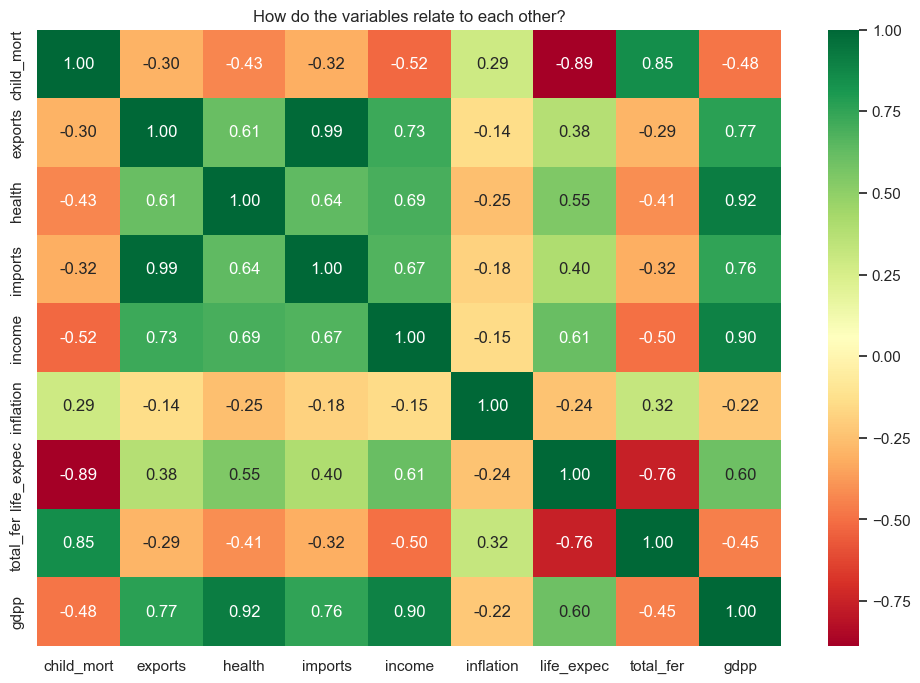

In [5]:
# EDA - The Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation_matrix = df.drop('country', axis=1).corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("How do the variables relate to each other?")
plt.show()

EDA Insights:
Inverse Correlation: There is a strong negative correlation between Income/GDP and Child Mortality. As a nation's wealth increases, child mortality rates drop significantly.

Economic Variance: The data shows massive disparities in wealth (GDP), suggesting that outliers (extremely wealthy nations) could skew the model if not handled correctly.

Health Indicator: Total Fertility and Child Mortality are positively correlated, indicating that countries with higher birth rates often struggle with healthcare infrastructure.

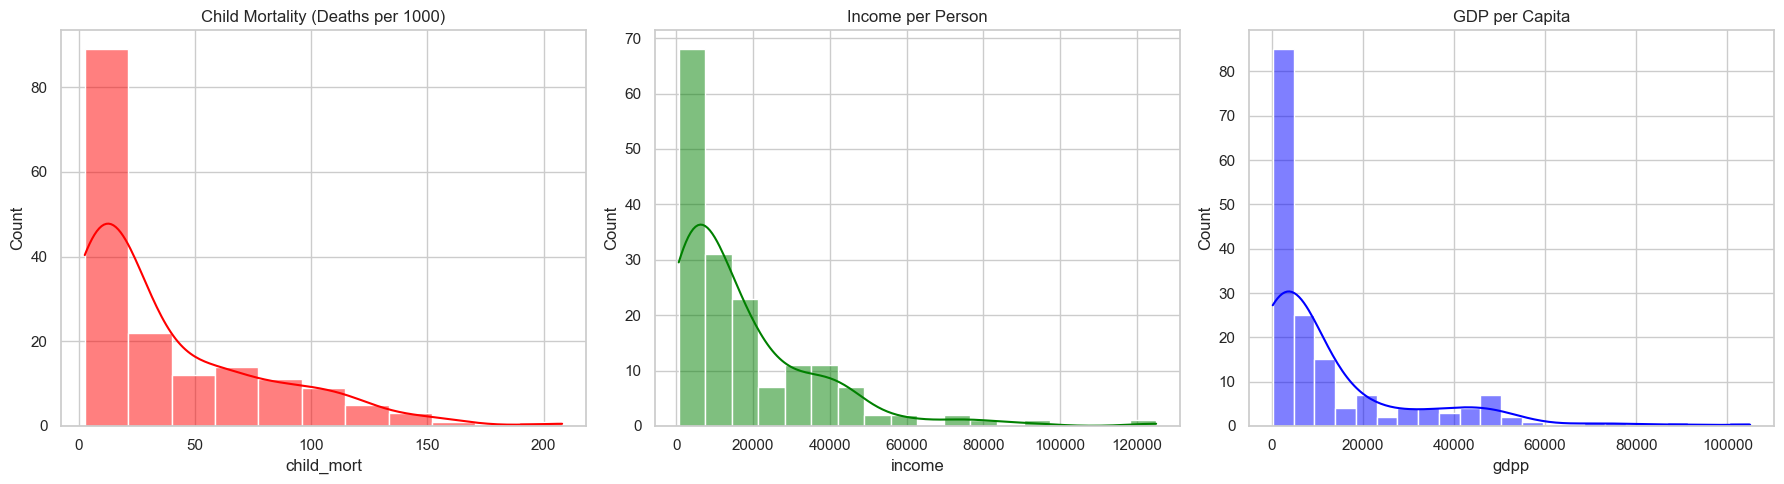

In [6]:
# Distribution Plots

plt.figure(figsize=(18, 5))

# Plot 1: Child Mortality (Health)
plt.subplot(1, 3, 1)
sns.histplot(df['child_mort'], kde=True, color='red')
plt.title('Child Mortality (Deaths per 1000)')

# Plot 2: Income (Wealth)
plt.subplot(1, 3, 2)
sns.histplot(df['income'], kde=True, color='green')
plt.title('Income per Person')

# Plot 3: GDPP (Economic development)
plt.subplot(1, 3, 3)
sns.histplot(df['gdpp'], kde=True, color='blue')
plt.title('GDP per Capita')

plt.tight_layout()
plt.show()

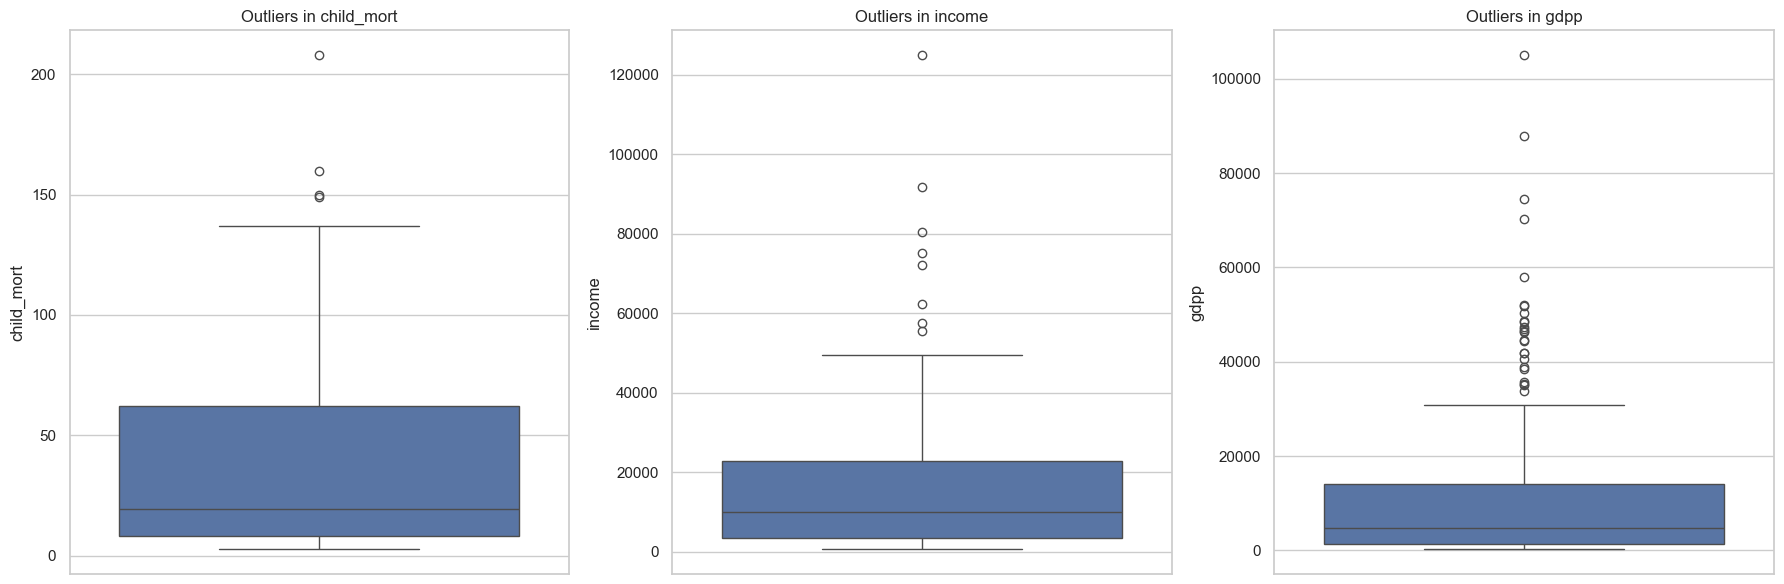

In [7]:
# Finding Outliers
plt.figure(figsize=(18, 6))

features_to_check = ['child_mort', 'income', 'gdpp']
for i, feature in enumerate(features_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[feature])
    plt.title(f'Outliers in {feature}')

plt.tight_layout()
plt.show()

In [8]:
# Scaling the Data
from sklearn.preprocessing import StandardScaler

data_for_scaling = df.drop('country', axis=1)

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data_for_scaling)

scaled_df = pd.DataFrame(scaled_data, columns=data_for_scaling.columns)

print("Data has been scaled! Here is a peek:")
scaled_df.head()

Data has been scaled! Here is a peek:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-0.411011,-0.565040,-0.432276,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.350191,-0.439218,-0.313677,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.318526,-0.484826,-0.353720,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,-0.291375,-0.532363,-0.345953,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,-0.104331,-0.178771,0.040735,0.101732,-0.601749,0.704258,-0.541946,-0.041817


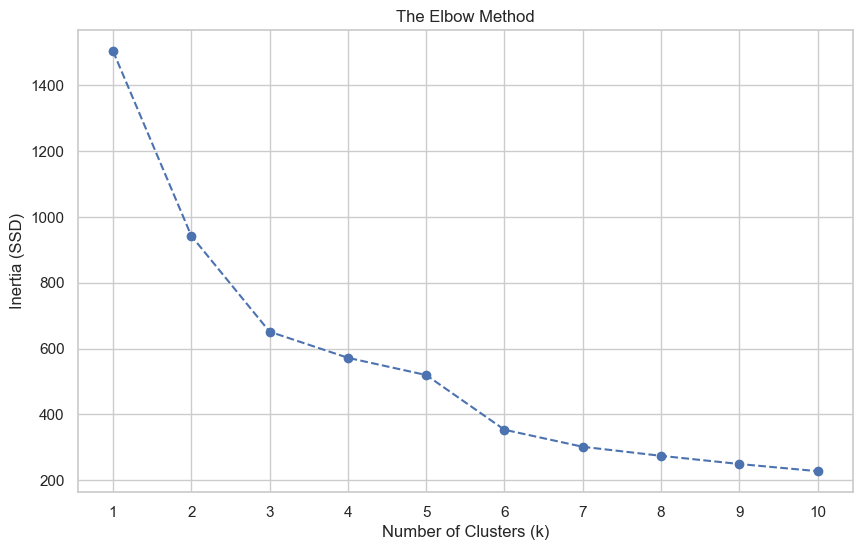

In [9]:
# Finding the Optimal Number of Clusters

from sklearn.cluster import KMeans

ssd = [] # This stands for Sum of Squared Distances
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    ssd.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), ssd, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSD)')
plt.xticks(range(1, 11))
plt.show()

In [10]:
# Final K-Means Model
# We set n_clusters=3 because that's where our "elbow" is!
kmeans_final = KMeans(n_clusters=3, random_state=42)
kmeans_final.fit(scaled_df)

df['cluster_id'] = kmeans_final.labels_

print("Number of countries in each cluster:")
print(df['cluster_id'].value_counts())

Number of countries in each cluster:
cluster_id
2    91
0    48
1    28
Name: count, dtype: int64


Average stats for each cluster:
            child_mort        income          gdpp
cluster_id                                        
0            91.610417   3897.354167   1909.208333
1             5.046429  50178.571429  48114.285714
2            20.357143  13968.021978   7979.912088


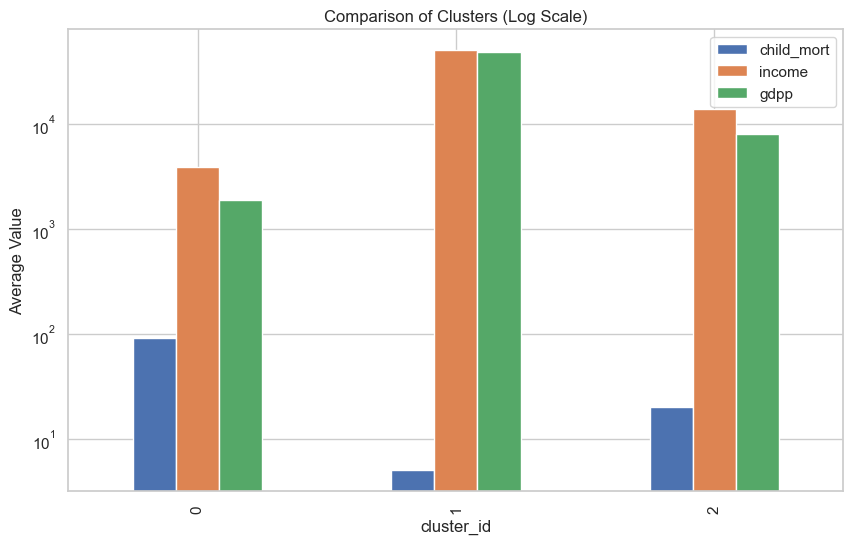

In [11]:
# Profiling the Clusters
# We group by cluster_id and look at the averages of key factors
cluster_profile = df.groupby('cluster_id')[['child_mort', 'income', 'gdpp']].mean()

print("Average stats for each cluster:")
print(cluster_profile)

cluster_profile.plot(kind='bar', logy=True, figsize=(10,6))
plt.title('Comparison of Clusters (Log Scale)')
plt.ylabel('Average Value')
plt.show()

Model Conclusion:
Optimal K Selection: Using the Elbow Method, we observed a significant drop in "Inertia" until k=3. Beyond 3 clusters, the rate of improvement slows down significantly.

Final Decision: We selected 3 clusters to represent "Developed," "Developing," and "Under-Developed" nations.

In [12]:
# The Countries in Dire Need
# We filter our data to show only countries in Cluster 0
dire_need_countries = df[df['cluster_id'] == 0]

# Let's sort them by Child Mortality (highest first) and then by GDP (lowest first)
# to see the absolute "priority" list
priority_list = dire_need_countries.sort_values(by=['child_mort', 'gdpp'], ascending=[False, True])

print("Top 10 Countries that need help the most:")
print(priority_list[['country', 'child_mort', 'income', 'gdpp']].head(10))

Top 10 Countries that need help the most:
                      country  child_mort  income  gdpp
66                      Haiti       208.0    1500   662
132              Sierra Leone       160.0    1220   399
32                       Chad       150.0    1930   897
31   Central African Republic       149.0     888   446
97                       Mali       137.0    1870   708
113                   Nigeria       130.0    5150  2330
112                     Niger       123.0     814   348
3                      Angola       119.0    5900  3530
37           Congo, Dem. Rep.       116.0     609   334
25               Burkina Faso       116.0    1430   575


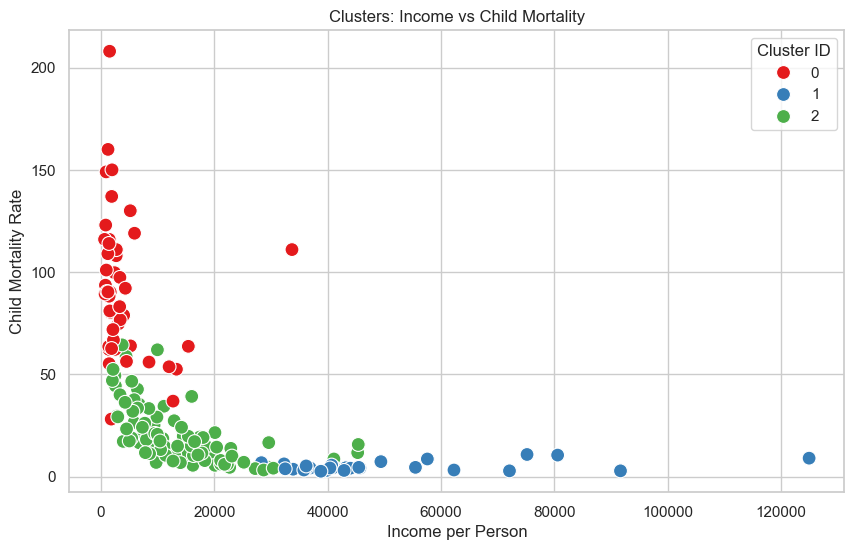

In [13]:
# Visualizing the Clusters
plt.figure(figsize=(10, 6))

# Income vs Child Mortality
sns.scatterplot(x='income', y='child_mort', hue='cluster_id', data=df, palette='Set1', s=100)

plt.title('Clusters: Income vs Child Mortality')
plt.xlabel('Income per Person')
plt.ylabel('Child Mortality Rate')
plt.legend(title='Cluster ID')
plt.show()

Cluster ID   Economic Status              Health Status           Priority Level
Cluster 0    Low Income Low GDP        High Child Mortality          CRITICAL
Cluster 2    Moderate Income           Moderate Health               Secondary
Cluster 1    High Income High GDP      Very Low Mortality            Low

In [14]:
# Exporting the final results to a CSV file
df.to_csv('Final_Country_Clusters.csv', index=False)
print("File 'Final_Country_Clusters.csv' has been saved to your folder!")

File 'Final_Country_Clusters.csv' has been saved to your folder!


Final Recommendation & Strategic Plan
Based on the K-Means clustering results, HELP International should focus its $10 million aid package exclusively on Cluster 0.

Top 5 Priority Countries:
Haiti (Highest Child Mortality: 208)

Sierra Leone

Chad

Central African Republic

Mali

Next Steps:
Targeted Healthcare: Since Cluster 0 is defined primarily by high child mortality, funds should be directed toward maternal health and vaccination programs.

Economic Stability: Because these countries also have the lowest GDP, a portion of the aid should support micro-financing to boost the average 'Income' metric.

Monitoring: Use the Tableau Dashboard to track progress in these specific regions over the next 5 years.

In [15]:
import pickle

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)
    
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)